In [1]:
import radarsimpy

print("`RadarSimPy` used in this example is version: " + str(radarsimpy.__version__))

`RadarSimPy` used in this example is version: 15.2.0


# Multipath Effect in Radar: Ground Reflection Analysis

**Multipath** occurs when signals travel via multiple routes (direct + ground reflections), creating constructive/destructive interference that causes amplitude fluctuations known as **multipath fading**.

**Four propagation paths (vertical multipath):**

| Path | Route | Notes |
|------|-------|-------|
| Direct | TX → Target → RX | Primary, shortest |
| TX reflection | TX → Ground → Target → RX | One bounce (TX side) |
| RX reflection | TX → Target → Ground → RX | One bounce (RX side) |
| Two-bounce | TX → Ground → Target → Ground → RX | Longest, most attenuated |

**Phase difference** between paths drives interference:
$$\Delta\phi = \frac{4\pi f_c \Delta L}{c}, \quad \Delta L \approx \frac{2h_r h_t}{R}$$

Null ranges (destructive interference): $R_{null} = \frac{4h_r h_t}{\lambda(2n-1)}$

### This Example

- **Radar**: 76.5 GHz FMCW, 160 MHz BW, monostatic
- **Scenario**: Corner reflector swept from 300 m → 10 m; ground with ε_r = 3.2 + 0.1j
- **Comparison**: With vs. without ground plane
- **Expected**: Free-space shows smooth 1/R⁴ decay; ground case shows amplitude lobing

## Radar System Configuration

In [ ]:
# Import necessary modules for radar simulation
import numpy as np
from radarsimpy import Radar, Transmitter, Receiver
import plotly.graph_objs as go
from IPython.display import Image, display

# Set to True for interactive plots; False renders a static JPEG (e.g. for HTML export)
INTERACTIVE = False


def show(fig):
    if INTERACTIVE:
        fig.show()
    else:
        display(Image(fig.to_image(format="jpg", scale=2)))

### Transmitter Configuration

| Parameter | Value | Notes |
|-----------|-------|-------|
| Frequency sweep | 76.42–76.58 GHz | 160 MHz BW, ΔR ≈ 0.94 m |
| Chirp duration | 20 μs | |
| TX power | 15 dBm | |
| PRP | 100 μs | |
| Pulses | 1 | Single chirp per frame |

Each of the 290 frames captures one snapshot; the target moves −1 m/s so its position advances 1 m per frame (300 m → 10 m).

In [ ]:
# Define transmitter antenna location
tx_channel = dict(
    location=(0, 0, 0),  # Position at origin (ground level for analysis)
)

# Configure FMCW transmitter
tx = Transmitter(
    f=[76.5e9 - 80e6, 76.5e9 + 80e6],  # Frequency sweep: 76.42-76.58 GHz (160 MHz BW)
    t=20e-6,  # Chirp duration: 20 μs
    tx_power=15,  # Transmit power: 15 dBm
    prp=100e-6,  # Pulse repetition period: 100 μs
    pulses=1,  # Single chirp per frame
    channels=[tx_channel],  # Transmitter antenna configuration
)

### Receiver Configuration

High baseband gain to resolve amplitude variations across the fading pattern. Maximum range: $R_{max} = \frac{f_s c T_c}{2B} \approx 300$ m.

| Parameter | Value |
|-----------|-------|
| Sampling rate `fs` | 20 MHz |
| Noise figure | 8 dB |
| RF gain | 20 dB |
| Baseband gain | 80 dB |
| Load resistor | 1000 Ω |

In [ ]:
# Define receiver antenna location
rx_channel = dict(
    location=(0, 0, 0),  # Co-located with transmitter (monostatic)
)

# Configure radar receiver
rx = Receiver(
    fs=20e6,  # Sampling rate: 20 MHz
    noise_figure=8,  # Noise figure: 8 dB
    rf_gain=20,  # RF gain: 20 dB
    load_resistor=1000,  # Load resistance: 1000 Ω (high impedance)
    baseband_gain=80,  # Baseband gain: 80 dB (high sensitivity)
    channels=[rx_channel],  # Receiver antenna configuration
)

### Create Radar System

`frame_time=np.arange(0, 290, 1)` schedules 290 measurement frames (one per second). Combined with the target's −1 m/s speed, each frame captures the return at a different range, building up the amplitude-vs-range profile.

In [14]:
# Create complete radar system with frame-based measurement
# frame_time: Array of times for each measurement [0, 1, 2, ..., 289] seconds
# Target moves -1 m/s, so position updates 1m per frame
radar = Radar(transmitter=tx, receiver=rx, frame_time=np.arange(0, 290, 1))

## Case 1: Corner Reflector with Ground Plane

The trihedral corner reflector moves from 300 m → 10 m while a 400 m × 400 m ground surface (ε_r = 3.2 + 0.1j, specular) introduces multipath. A Chebyshev-windowed range FFT extracts the peak amplitude at each of the 290 frames.

In [15]:
# Import simulation and processing modules
from radarsimpy.simulator import sim_radar
from scipy import signal
import radarsimpy.processing as proc
import time

# Configure corner reflector target (moving)
target_1 = {
    "model": "../models/cr.stl",  # Trihedral corner reflector
    "location": (300, 0, 0),  # Initial position: 300m along x-axis
    "speed": (-1, 0, 0),  # Velocity: -1 m/s approaching
}

# Configure ground surface
target_2 = {
    "model": "../models/surface_400x400.stl",  # 400m × 400m flat surface
    "location": (0, 0, -0.5),  # Position: 0.5m below radar
    "speed": (0, 0, 0),  # Stationary
    "permittivity": 3.2 + 0.1j,  # Complex permittivity (asphalt/concrete)
    "skip_diffusion": True,  # Specular reflection only
}

# Combine targets for multipath scenario
targets = [target_1, target_2]

# Start timing
tic = time.time()

# Simulate radar returns with multipath
# density=0.5: Ray tracing density for surfaces
# Simulates 290 frames (target moves 300m → 10m)
data = sim_radar(radar, targets, density=0.5)
baseband = data["baseband"]  # Complex I/Q samples

# Apply range FFT to extract range profiles
range_window = signal.windows.chebwin(radar.sample_prop["samples_per_pulse"], at=60)
range_profile = proc.range_fft(baseband, range_window)

# Extract peak amplitude per frame (max across range bins)
# Output: [290 frames, 1 channel] in dB
amp_multi = np.max(20 * np.log10(np.abs(range_profile)), axis=2)

# End timing
toc = time.time()
print("Exec time:", toc - tic, "s")

Exec time: 3.817408323287964 s


## Case 2: Corner Reflector without Ground Plane (Free Space)

Same target, no ground surface → only the direct path. Amplitude follows a smooth $1/R^4$ decay (−40 dB/decade), used as the free-space reference.

In [ ]:
# Configure corner reflector target (same as Case 1)
target_1 = {
    "model": "../models/cr.stl",  # Trihedral corner reflector
    "location": (300, 0, 0),  # Initial position: 300m
    "speed": (-1, 0, 0),  # Velocity: -1 m/s approaching
}

# Only target, no ground surface
targets = [target_1]

# Simulate radar returns in free space (no multipath)
data = sim_radar(radar, targets, density=0.5)
baseband = data["baseband"]

# Apply range FFT to extract range profiles
range_window = signal.windows.chebwin(radar.sample_prop["samples_per_pulse"], at=60)
range_profile = proc.range_fft(baseband, range_window)

# Extract peak amplitude per frame
# Output: [290 frames, 1 channel] in dB
amp_single = np.max(20 * np.log10(np.abs(range_profile)), axis=2)

## Results: Multipath Fading Pattern

- **Free-space (blue dashed)**: Smooth 1/R⁴ decay — single direct path.
- **With ground (orange)**: Oscillating lobing superimposed on the decay — constructive peaks where paths add in-phase, deep nulls where they cancel.
- Null positions shift with frequency, antenna height, and target height.

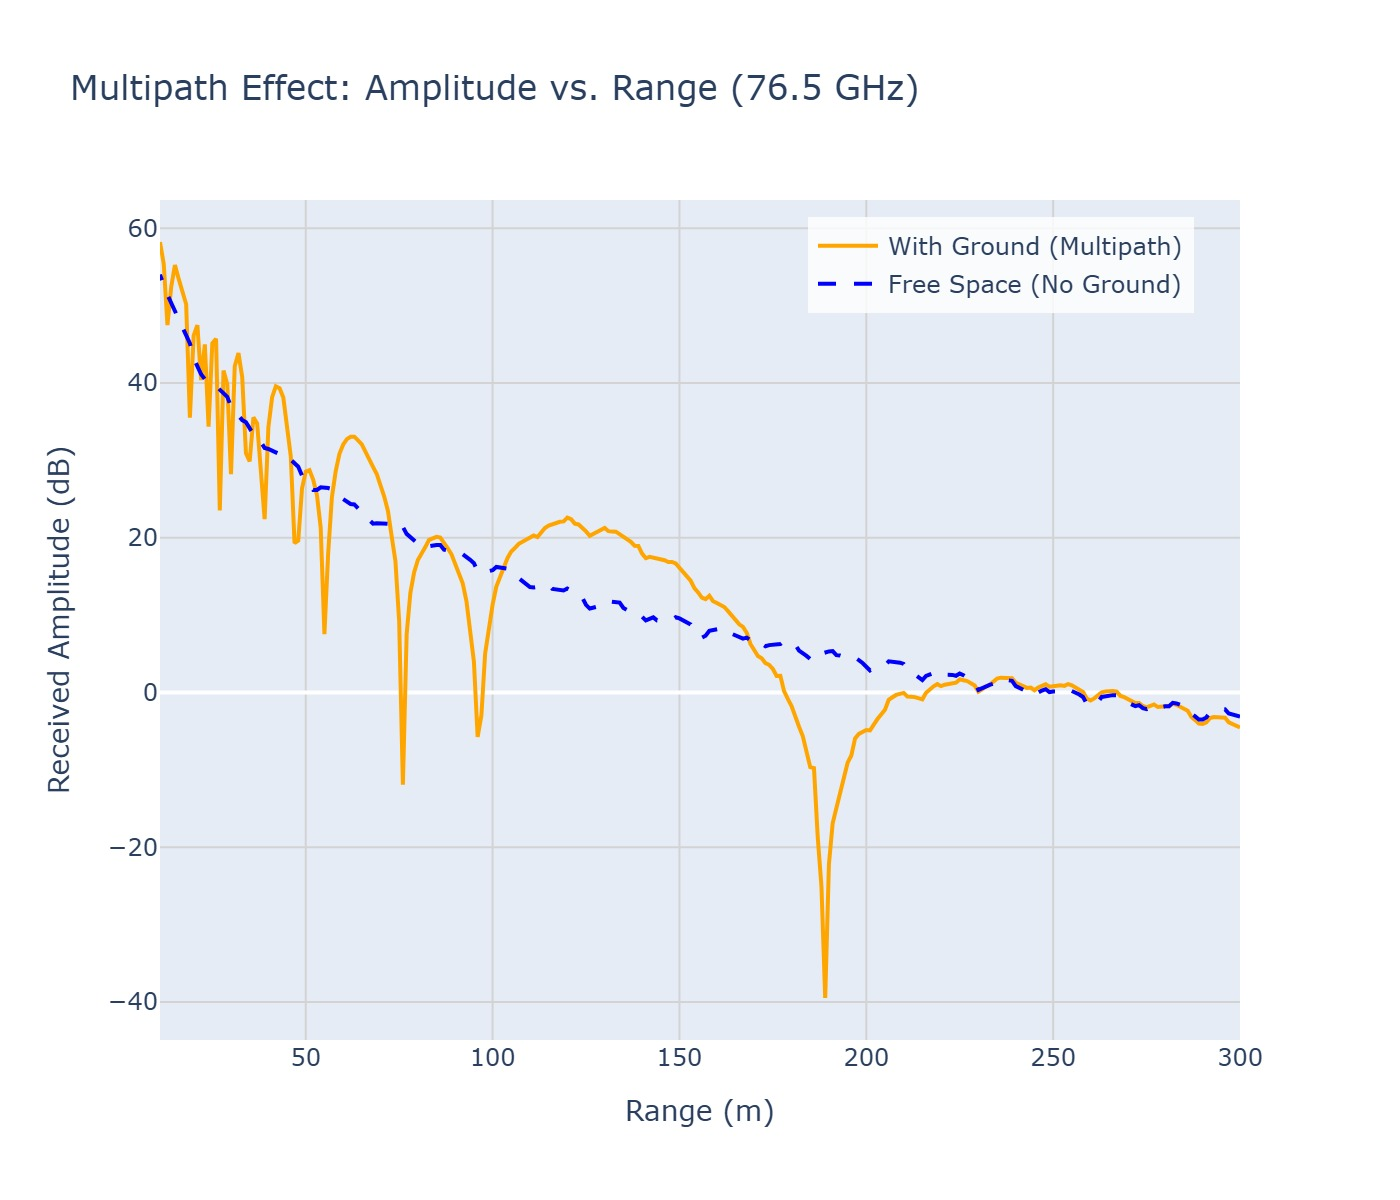

In [ ]:
# Range axis: target sweeps 300 m → 10 m over 290 frames
t_range = 10 + np.arange(290, 0, -1) * 1  # [300, 299, ..., 11] meters

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=t_range,
        y=amp_multi[:, 0],
        name="With Ground (Multipath)",
        line=dict(color="orange", width=2),
        mode="lines",
    )
)

fig.add_trace(
    go.Scatter(
        x=t_range,
        y=amp_single[:, 0],
        name="Free Space (No Ground)",
        line=dict(color="blue", width=2, dash="dash"),
        mode="lines",
    )
)

fig.update_layout(
    title="Multipath Effect: Amplitude vs. Range (76.5 GHz)",
    yaxis=dict(title="Received Amplitude (dB)", gridcolor="lightgray"),
    xaxis=dict(title="Range (m)", gridcolor="lightgray"),
    height=600,
    legend=dict(x=0.6, y=0.98, bgcolor="rgba(255,255,255,0.8)"),
    hovermode="x unified",
)

show(fig)

## Summary

- Multipath creates a **lobing pattern** by superimposing constructive/destructive interference on the 1/R⁴ free-space decay.
- Null positions are governed by $R_{null} = 4h_r h_t / [\lambda(2n-1)]$ — shift them by changing frequency, antenna height, or target height.
- Ground permittivity (ε_r = 3.2 + 0.1j) controls reflection amplitude and phase via the Fresnel coefficient.

### Things to Try

| Experiment | Parameter to change | Observable effect |
|------------|--------------------|--------------------|
| Shift null positions | Change `f` (frequency) | Lobing period scales with λ |
| Move first null closer/farther | Change radar/target height | $R_{null} \propto h_r h_t$ |
| Stronger/weaker reflections | Change `permittivity` | Deeper or shallower nulls |
| Different range sweep | Change target `location` / `speed` | More or fewer lobing cycles |
| Diffuse scattering | Set `skip_diffusion=False` | Softer nulls from rough surfaces |

### Resources

- [RadarSimPy Documentation](https://radarsimx.com/radarsimx/radarsimpy/)
- [Simulator Module API](https://radarsimx.github.io/radarsimpy/api/sim.html)